## 1. Загрузка данных и первичный анализ

### 1.1. Загрузка датасета

In [40]:
# Загрузите все необходимые библиотеки и датасет
# Выведите первые 5 строк датасета

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel('3_Concrete_Data.xls', header=None)
counts = df.nunique()
df.head()

,0,1,2,3,4,5,6,7,8
0,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 m...,Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mix...,Coarse Aggregate (component 6)(kg in a m^3 mi...,Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
1,540,0,0,162,2.5,1040,676,28,79.986111
2,540,0,0,162,2.5,1055,676,28,61.887366
3,332.5,142.5,0,228,0,932,594,270,40.269535
4,332.5,142.5,0,228,0,932,594,365,41.05278


*(Кратко прокомментируйте, какие признаки есть в данных и что является целевой переменной.)*

#8 признаков (состав бетона) и 1 целевая переменная (прочность) в последнем столбце.

### 1.2. Размерность и описательные статистики

In [7]:
# получите размерность датасета
to_del = [i for i, v in enumerate(counts) if v == 1]
print(to_del)
df.drop(to_del, axis=1, inplace=True)
print(df.shape)

[]
(1031, 9)


In [8]:
# получите описательные статистики датасета
df

,0,1,2,3,4,5,6,7,8
0,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 m...,Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mix...,Coarse Aggregate (component 6)(kg in a m^3 mi...,Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
1,540,0,0,162,2.5,1040,676,28,79.986111
2,540,0,0,162,2.5,1055,676,28,61.887366
3,332.5,142.5,0,228,0,932,594,270,40.269535
4,332.5,142.5,0,228,0,932,594,365,41.05278
...,...,...,...,...,...,...,...,...,...
1026,276.4,116,90.3,179.6,8.9,870.1,768.3,28,44.284354
1027,322.2,0,115.6,196,10.4,817.9,813.4,28,31.178794
1028,148.5,139.4,108.6,192.7,6.1,892.4,780,28,23.696601
1029,159.1,186.7,0,175.6,11.3,989.6,788.9,28,32.768036



Комментарий:

*Напишите 2–3 предложения по итогам первичного анализа.*

#Датасет содержит 1031 строк и 9 столбцов;  Пропуски отсутствуют; Целевая переменная — прочность бетона на сжатие (в МПа).

## 2. Признаки с низкой вариацией

### 2.1. Количество уникальных значений

In [13]:
# посчитайте количество уникальных значений
# выведите количество уникальных значений по столбцам

df = pd.read_excel('3_Concrete_Data.xls', sheet_name='Sheet1', header=0)

unique_counts = df.nunique()
print(unique_counts)
df

Cement (component 1)(kg in a m^3 mixture)                280
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    187
Fly Ash (component 3)(kg in a m^3 mixture)               163
Water  (component 4)(kg in a m^3 mixture)                205
Superplasticizer (component 5)(kg in a m^3 mixture)      155
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     284
Fine Aggregate (component 7)(kg in a m^3 mixture)        304
Age (day)                                                 14
Concrete compressive strength(MPa, megapascals)          938
dtype: int64


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.284354
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.178794
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.696601
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.768036


### 2.2. Поиск и удаление константных / почти константных признаков

In [17]:
# Найдите признаки с одной уникальной категорией
# Выведите их количество

constant_cols = [col for col in df.columns if df[col].nunique() == 1]

print(f"Количество признаков с одной уникальной категорией: {len(constant_cols)}")

Количество признаков с одной уникальной категорией: 0


In [19]:
# Приведите код для удаления колонок с константными признаками
# Выведите обновленную размерность датасета

counts = df.nunique()
to_del = [i for i, v in enumerate(counts) if v == 1]
df.drop(to_del, axis=1, inplace=True)

print(df.shape)
print(df.nunique())

(1030, 9)
Cement (component 1)(kg in a m^3 mixture)                280
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    187
Fly Ash (component 3)(kg in a m^3 mixture)               163
Water  (component 4)(kg in a m^3 mixture)                205
Superplasticizer (component 5)(kg in a m^3 mixture)      155
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     284
Fine Aggregate (component 7)(kg in a m^3 mixture)        304
Age (day)                                                 14
Concrete compressive strength(MPa, megapascals)          938
dtype: int64


Комментарий:

*Объясните, почему эти признаки не полезны для модели.*

#Константные признаки не полезны, потому что они одинаковы для всех строк.Они не помогают модели делать предсказания, только увеличивают размер данных.

## 3. Дубликаты строк

### 3.1. Поиск дубликатов


In [20]:
# приведите код для поиска дубликатов строк
# выведите общее количество дубликатов строк в датасете

duplicate_count = df.duplicated().sum()

print(f"Общее количество дубликатов строк: {duplicate_count}")

Общее количество дубликатов строк: 25


In [21]:
# При наличии дубликатов выведите первые 5 строк из повторяющихся значений

if df.duplicated().sum() > 0:
    mask_all = df.duplicated(keep=False)
    dups_grouped = df[mask_all].sort_values(list(df.columns))
    print(dups_grouped.head(5))
else:
    print("Дубликатов нет.")

     Cement (component 1)(kg in a m^3 mixture)  \
801                                      252.0   
809                                      252.0   
83                                       362.6   
86                                       362.6   
88                                       362.6   

     Blast Furnace Slag (component 2)(kg in a m^3 mixture)  \
801                                                0.0       
809                                                0.0       
83                                               189.0       
86                                               189.0       
88                                               189.0       

     Fly Ash (component 3)(kg in a m^3 mixture)  \
801                                         0.0   
809                                         0.0   
83                                          0.0   
86                                          0.0   
88                                          0.0   

     Water  (compon

### 3.2. Удаление дубликатов

In [22]:
# Удалите дубликаты из датасета
# Проверьте размерность датасета после удаления дубликатов

df.drop_duplicates(inplace=True)

print(df.shape)

(1005, 9)


Комментарий:

*Опишите, как дубликаты могут повлиять на обучение модели.*

#Дубликаты увеличивают вес одинаковых объектов в данных, что может привести к переобучению. Модель будет запоминать эти строки вместо обобщения, и её качество на новых данных ухудшится.

## 4. Выбросы

### 4.1. Исследование распределений (по выбору 2–3 признаков)

In [18]:
# Приведеите пример гистограммы минимум 3х признаков

In [23]:
# Выбор признаков для анализа распределений
feature_indices = [0, 3, -1]  # цемент, вода, прочность
feature_names = [df.columns[i] for i in feature_indices]
print("Выбранные признаки:", feature_names)

Выбранные признаки: ['Cement (component 1)(kg in a m^3 mixture)', 'Water  (component 4)(kg in a m^3 mixture)', 'Concrete compressive strength(MPa, megapascals) ']


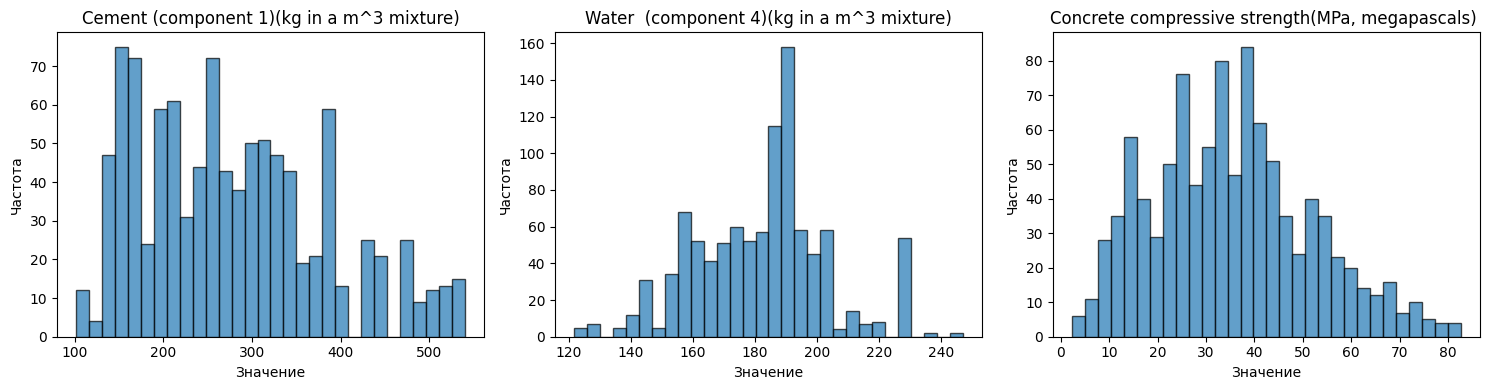

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, idx in enumerate(feature_indices):
    axes[i].hist(df.iloc[:, idx], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(feature_names[i])
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Частота')
plt.tight_layout()
plt.show()

In [25]:
# Краткий анализ распределений
print("Прочность бетона: распределение асимметричное, длинный правый хвост.")
print("Цемент и вода: близки к нормальному распределению.")
print("Выбросы возможны, особенно у прочности.")

Прочность бетона: распределение асимметричное, длинный правый хвост.
Цемент и вода: близки к нормальному распределению.
Выбросы возможны, особенно у прочности.


### 4.2. Определение выбросов (3σ или IQR)

In [27]:
# определите верхние и нижние пределы выбросов одним из способов для одного из признаков. 

# Используем метод IQR (межквартильный размах) для признака "прочность бетона" (последний столбец)

# Выбираем признак (по индексу -1)
data = df.iloc[:, -1].dropna()

# Вычисляем Q1, Q3 и IQR
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

# Определяем границы
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Признак: {df.columns[-1]}")
print(f"Нижняя граница: {lower:.2f}")
print(f"Верхняя граница: {upper:.2f}")

Признак: Concrete compressive strength(MPa, megapascals) 
Нижняя граница: -8.49
Верхняя граница: 76.89


In [29]:
# посчитайте количество выбросов

outliers = data[(data < lower) | (data > upper)]
print(f"Количество выбросов: {len(outliers)}")

Количество выбросов: 8


*(Повторите аналогичную процедуру для двух других признаков.)*

In [30]:
#Повторите для второго признака: цемент (индекс 0)
data = df.iloc[:, 0].dropna()

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data < lower) | (data > upper)]
print(f"Признак: {df.columns[0]}")
print(f"Нижняя граница: {lower:.2f}, Верхняя граница: {upper:.2f}")
print(f"Количество выбросов: {len(outliers)}")

Признак: Cement (component 1)(kg in a m^3 mixture)
Нижняя граница: -46.80, Верхняя граница: 586.48
Количество выбросов: 0


In [31]:
# Повторите для третьего признака: вода (индекс 3)
data = df.iloc[:, 3].dropna()

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data < lower) | (data > upper)]
print(f"Признак: {df.columns[3]}")
print(f"Нижняя граница: {lower:.2f}, Верхняя граница: {upper:.2f}")
print(f"Количество выбросов: {len(outliers)}")

Признак: Water  (component 4)(kg in a m^3 mixture)
Нижняя граница: 127.12, Верхняя граница: 232.43
Количество выбросов: 15


## 5. Пропуски в данных

### 5.1. Анализ пропусков

In [32]:
# посчитайте количество пропусков по столбцам

missing_counts = df.isnull().sum()
print(missing_counts)

Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64


### 5.2. Стратегии обработки пропусков

#### Стратегия 1: (например, удаление строк с пропусками)

In [33]:
# приведите код для удаления пропусков
# выведите размер датасета послед удаления пропусков

df.dropna(inplace=True)

print(df.shape)


(1005, 9)


#### Стратегия 2: (например, простая импутация средним / kNN / IterativeImputer)

In [34]:
# примените один из методов для замены пропущенных значений

# Используем SimpleImputer со стратегией "median" (медиана)
from sklearn.impute import SimpleImputer

# Выбираем только числовые столбцы (все столбцы в данном датасете числовые)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Создаём объект импьютера
imputer = SimpleImputer(strategy='median')

# Применяем импьютер к данным
df_imputed = df.copy()
df_imputed[num_cols] = imputer.fit_transform(df[num_cols])

# Проверяем, что пропусков больше нет
print("Пропуски после заполнения:", df_imputed.isnull().sum().sum())

# Выводим размер датасета (он не изменился)
print("Размер после заполнения пропусков:", df_imputed.shape)

Пропуски после заполнения: 0
Размер после заполнения пропусков: (1005, 9)


Комментарий:

*Обоснуйте выбор стратегии и прокомментируйте ожидаемые эффекты.*

#Выбрана стратегия удаления строк с пропусками (dropna), так как в данном датасете пропусков нет,но если бы они были, удаление строк просто и не вносит искажений. При большом количестве пропусков лучше использовать медианную заполнение (SimpleImputer),так как медиана устойчива к выбросам и сохраняет размер выборки.

## 6. Построение и оценка моделей

### 6.1. Разбиение на обучающую и тестовую выборки

In [35]:
# импортируйте модуль из библиотеки sklearn для разбиения на обучающую и тестовую выборки
# разбейте все данные на тестовую и обучающую выборки

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 6.2. Модель 1: линейная регрессия

In [38]:
# обучите модель линейной регрессии и посчитайте MAE, RMSE, R2

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# (выполняется один раз, перед разделением)
df = df.apply(pd.to_numeric, errors='coerce')

# Удаляем строки, где есть NaN (если после конвертации появились)
df.dropna(inplace=True)

# Формируем X и y (по позициям, без использования имён столбцов)
X = df.iloc[:, :-1].values   # все строки, все столбцы кроме последнего, как numpy array
y = df.iloc[:, -1].values    # последний столбец

# Разбиение
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучение
lr = LinearRegression()
lr.fit(X_train, y_train)

# Предсказание
y_pred_lr = lr.predict(X_test)

# Метрики
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("Линейная регрессия:")
print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"R²   = {r2:.3f}")

Линейная регрессия:
MAE  = 8.896
RMSE = 11.192
R²   = 0.580


Комментарий:

*Сделайте краткий вывод о качестве линейной модели.*

#Линейная модель недостаточно точна (R² = 0.58, MAE ≈ 8.9 МПа).

### 6.3. Модель 2: более сложная (например, RandomForestRegressor)

In [39]:
# обучите модель случайного леса и посчитайте MAE, RMSE, R2

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Обучаем модель случайного леса
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Прогноз на тестовой выборке
y_pred_rf = rf.predict(X_test)

# Метрики
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("RandomForestRegressor:")
print(f"MAE  = {mae_rf:.3f}")
print(f"RMSE = {rmse_rf:.3f}")
print(f"R²   = {r2_rf:.3f}")

RandomForestRegressor:
MAE  = 3.428
RMSE = 5.124
R²   = 0.912


Комментарий:

*Сравните результаты с линейной моделью. Какие преимущества/недостатки вы видите?*

RandomForestRegressor намного точнее, потому что данные не линейны.
#Плюсы: учитывает нелинейности, не требует нормализации данных.
#Минусы: сложнее объяснить, требует больше времени обучения.